### 1. 核心类总结

| 类 | 所属分支 | 作用 | 典型场景 |
|---|---|---|---|
| `BasePromptTemplate` | 基类 | 所有提示模板的抽象基类 | 一般不直接实例化 |
| `PromptTemplate` | 字符串 | 用 `{变量}` 占位的字符串模板 | 纯文本模型 / 快速拼一段话 |
| `ChatPromptTemplate` | 聊天 | 维护一条**消息列表**的模板 | GPT 系列等聊天模型（最常用） |
| `SystemMessagePromptTemplate` | 消息组件 | 系统消息模板 | 设定人设、规则 |
| `HumanMessagePromptTemplate` | 消息组件 | 用户消息模板 | 用户输入 |
| `AIMessagePromptTemplate` | 消息组件 | AI 消息模板 | 历史对话、示例 |
| `MessagesPlaceholder` | 消息组件 | 占位符，运行时塞一段消息列表 | 动态插入历史记录 |
| `FewShotPromptTemplate` | 字符串 | 少样本（few-shot）字符串模板 | 给纯文本模型几个示例 |
| `FewShotChatMessagePromptTemplate` | 聊天 | 少样本聊天模板 | 给聊天模型几个示例 |
| `PipelinePromptTemplate` | 字符串 | 管道拼接多个模板 | 已弃用（新版移除），仅了解 |

> 记忆点：`PromptTemplate` 产出的是**字符串**；`ChatPromptTemplate` 产出的是**消息对象列表**。凡是要发给聊天模型的，用后者。

---

### 2. 关键参数

| 参数 | 用在 | 作用 |
|---|---|---|
| `template` | PromptTemplate | 模板文本，`{变量}` 占位 |
| `input_variables` | PromptTemplate | 声明需要外部传入的变量名 |
| `partial_variables` | 两者 | 构造时就预填好的变量 |
| `validate_template` | PromptTemplate | 是否校验模板（默认 True） |
| `messages` | ChatPromptTemplate | 消息模板列表 |
| `variables` | MessagesPlaceholder | 占位符对应的变量名 |
| `examples` | FewShot 系 | 示例列表（list of dict） |
| `example_prompt` | FewShot 系 | 单个示例如何格式化的模板 |
| `prefix` / `suffix` | FewShotPromptTemplate | 示例前后的固定文字 |
| `final_prompt` + `pipeline_prompts` | PipelinePromptTemplate | 总模板 + 子模板映射 |

---

### 一句话总结

字符串场景用 `PromptTemplate` + `format`；聊天场景用 `ChatPromptTemplate.from_messages` + `format_messages`/`invoke`；历史记录用 `MessagesPlaceholder`；给示例用 `FewShot*`；固定部分用 `partial`；踩坑重点是**花括号转义**和**变量对齐**。

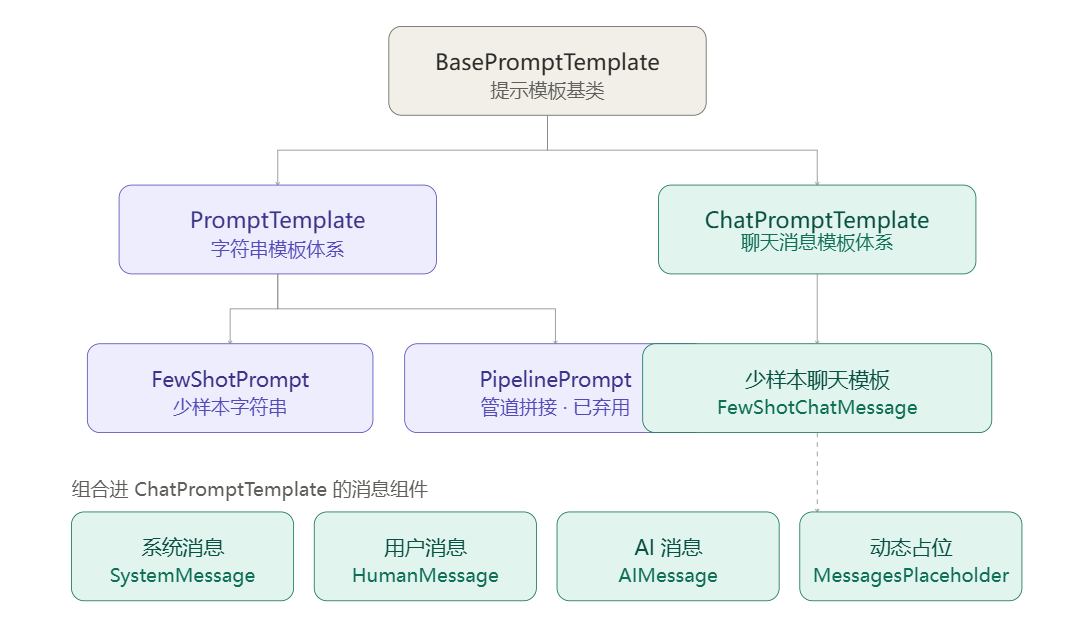

## Deepseek模型初始化

In [1]:
from langchain.chat_models import init_chat_model
model = init_chat_model(model="deepseek-flash")

## PromtTemplate-LLM提示模板（String）

In [23]:
from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template(template="你是一个翻译助手，请讲以下内容翻译成{language}:{text}")

# 方式一：format 返回字符串
prompt= prompt_template.format(language="中文", text="I am a programmer")
print(type(prompt))
print(prompt)

model.invoke(prompt).content

<class 'str'>
你是一个翻译助手，请讲以下内容翻译成中文:I am a programmer


'我是一个程序员'

## ChatPromtTemplate-聊天提示模版

In [2]:
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate, AIMessagePromptTemplate

# prompt_template = ChatPromptTemplate.from_messages([
#     ("system", "你是一个翻译助手，请将以下内容翻译成{language}"),
#     ("human", "{text}"),
# ])

# 设置对话提示词模板，设置角色
prompt_template = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template("你是一个翻译助手，请将以下内容翻译成{language}"),
    HumanMessagePromptTemplate.from_template("{text}")
    # AIMessagePromptTemplate  ai的角色消息，用来记录维持对话
])

# 输入参数内容，构建真正的提示词
prompt = prompt_template.format(language="中文", text="I am a programmer")
print(type(prompt))
print(prompt)

model.invoke(prompt).content

<class 'str'>
System: 你是一个翻译助手，请将以下内容翻译成中文
Human: I am a programmer


'我是一个程序员。'

## FewShotPromptTemplate-少样本提示模版

In [21]:
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate

# 创建示例
examples = [
    {"input": "2+2", "output": "4", "description": "加法运算"},
    {"input": "5-2", "output": "3", "description": "减法运算"},
]

# 这是一个提示模板的实例，用于设置每个示例的格式
prompt_sample = PromptTemplate.from_template(template="算式： {input} 值： {output} 类型： {description}")

# 创建少样本示例的对象
prompt = FewShotPromptTemplate(
    examples=examples, # 示例样本
    example_prompt=prompt_sample, # 示例的提示模板
    prefix="你是一个数学专家, 能够准确说出算式的类型，", # 前缀：提示词前面
    suffix="现在给你算式: {input} ， 值: {output} ，告诉我类型：", # 后缀：提示词后面
    input_variables=["input", "output"]
)
print(prompt.format(input="2*5", output="10"))  # 你是一个数学专家,算式: 2*5  值: 10

print('-' * 50)

result = model.invoke(prompt.format(input="2*5", output="10"))
print(result.content)  # 使用: 乘法运算

你是一个数学专家, 能够准确说出算式的类型，

算式： 2+2 值： 4 类型： 加法运算

算式： 5-2 值： 3 类型： 减法运算

现在给你算式: 2*5 ， 值: 10 ，告诉我类型：
--------------------------------------------------
类型：乘法运算


In [22]:
# 创建示例，模型学习用户给的参照样本，安装样本进行回答
examples = [
    {"input": "如何重置密码？", "output": "密码重置可以通过绑定邮箱重置密码，也可以通过手机号重置密码"},
    {"input": "我的设备无法开机怎么办？", "output": "故障排除步骤：1.可能是遥控器电池没电，2.确认电源状态，3.确认设备是否被锁屏"},
    {"input": "这款产品是否有夜间模式？", "output": "这款不提供夜间模式，请选择xx款式的产品"},
]

# 这是一个提示模板的实例，用于设置每个示例的格式
prompt_sample = PromptTemplate.from_template(template="用户问题： {input} 对应回答： {output}")

# 创建少样本示例的对象
prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=prompt_sample,
    prefix="你是一个智能客服, 能够根据用户问题给出答案，",
    suffix="现在给你用户提问: {input} ，请告诉我对应的结果：",
    input_variables=["input"]
)
print(prompt.format(input="这款产品有防水模式？"))

print('-' * 50)

result = model.invoke(prompt.format(input="这款产品有防水模式？"))
print(result.content)

你是一个智能客服, 能够根据用户问题给出答案，

用户问题： 如何重置密码？ 对应回答： 密码重置可以通过绑定邮箱重置密码，也可以通过手机号重置密码

用户问题： 我的设备无法开机怎么办？ 对应回答： 故障排除步骤：1.可能是遥控器电池没电，2.确认电源状态，3.确认设备是否被锁屏

用户问题： 这款产品是否有夜间模式？ 对应回答： 这款不提供夜间模式，请选择xx款式的产品

现在给你用户提问: 这款产品有防水模式？ ，请告诉我对应的结果：
--------------------------------------------------
这款产品不提供防水模式，请选择xx款式的产品。


### Partial-部分变量提前填好(了解)

In [7]:
# 作用这是参数，提前先设置一个参数，后续在设置其他参数，分开给不同参数赋值
# 比如：实现学习助手，在提问前先设置学科，在输入内容问题

from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate.from_template("{greeting}，{name}！今天{weather}。")
# greeting 提前定死，运行时只填 name / weather
partial_prompt = prompt_template.partial(greeting="你好")
print(partial_prompt)
prompt = partial_prompt.format(name="小明", weather="晴天")
print(prompt)
# 你好，小明！今天晴天。
# 坑：已经 partial 掉的 greeting，调用时不要再传
model.invoke(prompt).content

input_variables=['name', 'weather'] input_types={} partial_variables={'greeting': '你好'} template='{greeting}，{name}！今天{weather}。'
你好，小明！今天晴天。


'你好！不过我不是小明，我是AI助手。今天晴天真不错，心情也会好一些～有什么我可以帮你的吗？'